# Esports share of Twitch

**Purpose:** `docs/esports_gauses_law_brief.md` motivates this project with a
claim that esports' share of overall Twitch attention has declined since its
early-2020s peak, displaced by other content. This notebook tests that claim
directly against the Kaggle "Evolution of Top Games on Twitch" dataset
(monthly top-200 category figures, 2016 onward — see
`collectors/kaggle_import.py` for the dataset's own documented provenance
and caveats), independent of and reading the raw CSV directly rather than
`monthly_category_history` (which currently only holds whatever subset of
the 23 tracked titles this dataset can be mapped to via
`NAME_TO_TITLE_ID` — that mapping's own count is confirmed directly below,
not assumed, since a mapping fix made while building this notebook changed
it).

**First question, resolved before computing anything** (per explicit
instruction): does Twitch's own top-200 ranking include non-game categories
(Just Chatting, IRL, Music, etc.), or is it games-only? This determines
whether "esports share of Twitch" is even the right description of what
follows, or whether it's actually the narrower "esports share of top-200
games." The next section answers this directly, before any metric is
computed.

In [1]:
# Imports and repo path setup — same pattern as category_trajectories.ipynb / reconciliation.ipynb.
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt

from analysis.metrics import _normalize_tier
from collectors.kaggle_import import NAME_TO_TITLE_ID
from etl.db import get_connection

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
KAGGLE_CSV.is_file()

True

In [2]:
# cp1252, not utf-8 — same encoding fix collectors/kaggle_import.py already
# documents and applies (some game names contain non-ASCII punctuation that
# isn't valid UTF-8 but decodes cleanly as cp1252).
raw = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
raw["year_month"] = raw["Year"].astype(str).str.zfill(4) + "-" + raw["Month"].astype(str).str.zfill(2)

rows_per_month = raw.groupby("year_month").size()
print(f"{len(raw)} rows across {raw['year_month'].nunique()} months")
print(f"month range: {raw['year_month'].min()} .. {raw['year_month'].max()}")
print(f"rows per month: min={rows_per_month.min()}, max={rows_per_month.max()} "
      f"(confirms a fixed top-{rows_per_month.max()} ranking every month)")

21000 rows across 105 months
month range: 2016-01 .. 2024-09
rows per month: min=200, max=200 (confirms a fixed top-200 ranking every month)


In [3]:
# Twitch's own category taxonomy has no "is this a game" flag anywhere in
# this CSV — Rank/Hours_watched/etc. are computed identically for a game and
# for a lifestyle/IRL category. This list is manually verified against
# Twitch's actual known non-game directory categories (checked each
# candidate's total hours_watched and month-coverage below to confirm it's
# a real, recurring category in the data, not a one-off coincidental name
# match) — a documented judgment call, not something inferred automatically
# from the file alone.
NON_GAME_CATEGORIES = {
    "ASMR", "Art", "Beauty & Body Art", "Casino", "Fitness & Health",
    "Food & Drink", "IRL", "Just Chatting", "Makers & Crafting", "Music",
    "Politics", "Pools, Hot Tubs, and Beaches", "Science & Technology",
    "Slots", "Software and Game Development", "Special Events",
    "Talk Shows & Podcasts", "Travel & Outdoors",
}

verify = (
    raw[raw["Game"].isin(NON_GAME_CATEGORIES)]
    .groupby("Game")
    .agg(total_hours=("Hours_watched", "sum"), months_present=("year_month", "nunique"))
    .sort_values("total_hours", ascending=False)
)
print(verify.to_string())
missing = NON_GAME_CATEGORIES - set(verify.index)
assert not missing, f"expected non-game categories not found in the data at all: {missing}"

just_chatting_present = "Just Chatting" in raw["Game"].values
print()
print(f"Just Chatting present in the ranked list: {just_chatting_present} "
      f"({verify.loc['Just Chatting', 'months_present']}/{raw['year_month'].nunique()} months)")

                               total_hours  months_present
Game                                                      
Just Chatting                  14397469625              73
Slots                           1208103879              70
Music                           1147942190             105
Special Events                   770536855              72
IRL                              662772269              34
Talk Shows & Podcasts            566500310             105
ASMR                             547766607              73
Art                              537991909              73
Pools, Hot Tubs, and Beaches     176367734              41
Travel & Outdoors                150842654              61
Food & Drink                     122219890              72
Casino                           113683474              11
Science & Technology              75851422              50
Software and Game Development     57365302              37
Makers & Crafting                 55124327              

In [4]:
print(
    "CONCLUSION: Twitch's top-200 ranking is NOT games-only — "
    f"{len(NON_GAME_CATEGORIES)} confirmed non-game categories (Just Chatting, IRL, Music, "
    "Special Events, and others above) appear repeatedly, several of them (Just Chatting "
    "especially) among the largest entries by hours_watched in most months.\n\n"
    "This means 'esports share of Twitch' IS testable here, but precisely means:\n"
    "  esports share of the TOP-200 RANKED TWITCH CATEGORIES each month (games + non-game "
    "content together) — narrower than literally all of Twitch (anything ranked below "
    "200 in a given month is excluded from both numerator and denominator), but broader "
    "than 'top-200 games only' would be, since non-game content sits in the denominator too.\n\n"
    "Every 'esports share' figure below should be read with that framing, not as a share "
    "of the platform's entire, unranked long tail."
)

CONCLUSION: Twitch's top-200 ranking is NOT games-only — 18 confirmed non-game categories (Just Chatting, IRL, Music, Special Events, and others above) appear repeatedly, several of them (Just Chatting especially) among the largest entries by hours_watched in most months.

This means 'esports share of Twitch' IS testable here, but precisely means:
  esports share of the TOP-200 RANKED TWITCH CATEGORIES each month (games + non-game content together) — narrower than literally all of Twitch (anything ranked below 200 in a given month is excluded from both numerator and denominator), but broader than 'top-200 games only' would be, since non-game content sits in the denominator too.

Every 'esports share' figure below should be read with that framing, not as a share of the platform's entire, unranked long tail.


## Scope note: all 23 tracked titles now map — one was wrongly excluded, found and fixed here

`collectors/kaggle_import.py`'s `NAME_TO_TITLE_ID` originally excluded all
four fighting-game titles (`tekken`, `street_fighter`, `mortal_kombat`,
`guilty_gear`) entirely, reasoning that the dataset's raw category names
can't reliably distinguish generations (a raw "Tekken" could be Tekken 7,
which predates this project's tracked Tekken 8).

**That blanket exclusion was too broad.** Building this notebook surfaced
that `Street Fighter 6` is an unambiguous, current-generation Kaggle name —
excluding it was a real coverage-bias bug, not a deliberate choice. Checked
the other three at the same time, same standard (exact, unambiguous
current-generation name only): `TEKKEN 8`, `Mortal Kombat 1`, and
`Guilty Gear: Strive` all exist as clean, unambiguous entries too. All four
are now mapped in `NAME_TO_TITLE_ID`; older/ambiguous names for the same
franchises (`Tekken 7`, `Street Fighter V`, `Mortal Kombat 11`/`X`,
`Guilty Gear Xrd: Revelator`/`Rev 2`, etc.) correctly stay excluded — same
reasoning as before, just no longer applied to the current generation by
mistake.

**Result: all 23 tracked titles now match**, confirmed (not assumed) in
the next cell.

In [5]:
matched_names = {name.lower() for name in NAME_TO_TITLE_ID}
raw["title_id"] = raw["Game"].str.strip().str.lower().map(NAME_TO_TITLE_ID)
matched = raw.dropna(subset=["title_id"]).copy()

# Some title_ids map from more than one raw Kaggle "Game" name in the same
# month (the CS2/CS:GO and Overwatch/Overwatch 2 launch transitions) —
# groupby-sum here is what makes that additive rather than an overwrite;
# collectors/kaggle_import.py's own docstring documents the real bug a naive
# per-row upsert caused for exactly these two transitions.
title_monthly = (
    matched.groupby(["title_id", "year_month"], as_index=False)["Hours_watched"].sum()
)

matched_ids = sorted(title_monthly["title_id"].unique())
print(f"{len(matched_ids)}/{len(set(NAME_TO_TITLE_ID.values()))} mapped title_ids have at least one matched row")
missing_ids = sorted(set(NAME_TO_TITLE_ID.values()) - set(matched_ids))
if missing_ids:
    print(f"[warn] mapped title_id(s) with ZERO matching rows — mapping drift: {missing_ids}")
else:
    print("no title_id is missing entirely — mapping still matches the file's actual spelling")

print()
print("CS2 transition (Counter-Strike, ~2023-09) sanity check:")
print(title_monthly[(title_monthly.title_id == "counter_strike") & (title_monthly.year_month.between("2023-06", "2023-12"))]
      .to_string(index=False))
print()
print("Overwatch 2 transition (~2022-10) sanity check:")
print(title_monthly[(title_monthly.title_id == "overwatch") & (title_monthly.year_month.between("2022-07", "2023-01"))]
      .to_string(index=False))

23/23 mapped title_ids have at least one matched row
no title_id is missing entirely — mapping still matches the file's actual spelling

CS2 transition (Counter-Strike, ~2023-09) sanity check:
      title_id year_month  Hours_watched
counter_strike    2023-06       44628452
counter_strike    2023-07       60158134
counter_strike    2023-08       62909824
counter_strike    2023-09       45918898
counter_strike    2023-10       64312173
counter_strike    2023-11       43726023
counter_strike    2023-12       36856925

Overwatch 2 transition (~2022-10) sanity check:
 title_id year_month  Hours_watched
overwatch    2022-07        8274836
overwatch    2022-08        5369471
overwatch    2022-09        6139776
overwatch    2022-10      139453660
overwatch    2022-11       47612487
overwatch    2022-12       43060315
overwatch    2023-01       25907337


## Core metric: esports share of top-200 Twitch attention

`esports_share[month] = (sum of the matched tracked titles' hours_watched) /
(sum of all 200 ranked categories' hours_watched that month)`. Plotted
against `Just Chatting`'s own share (the specific "if not esports, then
what" comparison) and the combined share of every confirmed non-game
category, for a fuller picture of where attention actually went.

Data runs 2016-01 through **2024-09** — the dataset's own last month, not
"to present" (today is well past that; there is no more recent data in this
source).

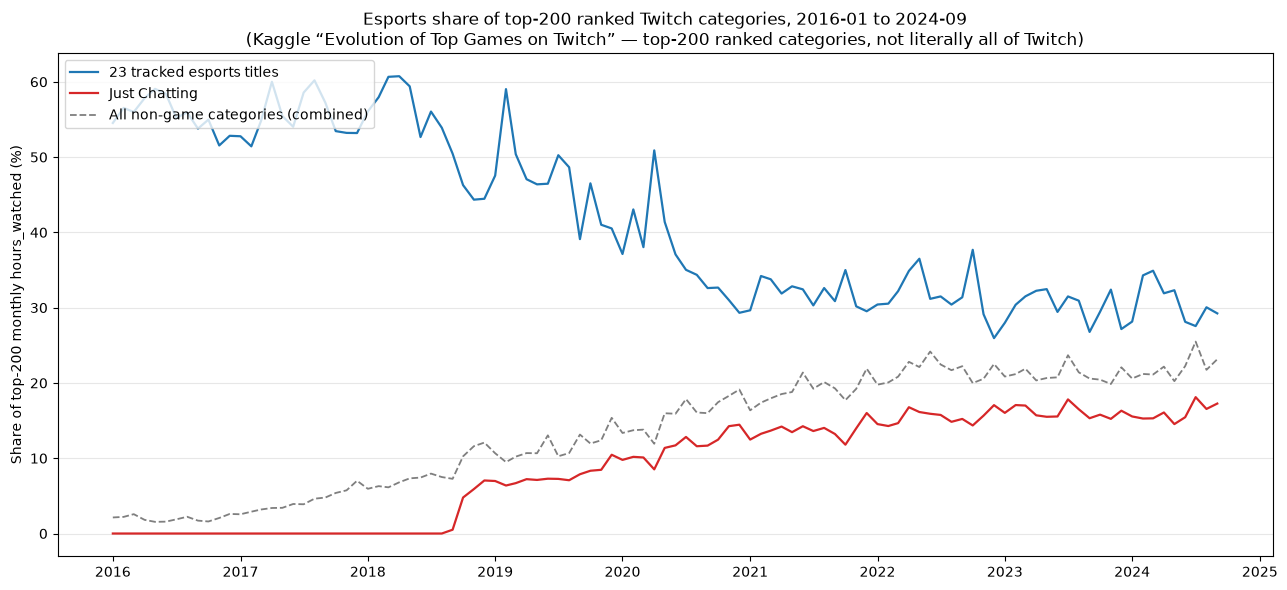

     month  esports_share  just_chatting_share  non_game_share
2016-01-01       0.545348             0.000000        0.021347
2024-09-01       0.292420             0.172618        0.231503


In [6]:
monthly_total = raw.groupby("year_month")["Hours_watched"].sum().rename("total_hours")
esports_monthly = title_monthly.groupby("year_month")["Hours_watched"].sum().rename("esports_hours")
just_chatting_monthly = (
    raw[raw["Game"] == "Just Chatting"].groupby("year_month")["Hours_watched"].sum().rename("jc_hours")
)
non_game_monthly = (
    raw[raw["Game"].isin(NON_GAME_CATEGORIES)].groupby("year_month")["Hours_watched"].sum().rename("non_game_hours")
)

share_df = pd.concat([monthly_total, esports_monthly, just_chatting_monthly, non_game_monthly], axis=1).fillna(0)
share_df["month"] = pd.to_datetime(share_df.index + "-01")
share_df = share_df.sort_values("month").reset_index(drop=True)
share_df["esports_share"] = share_df["esports_hours"] / share_df["total_hours"]
share_df["just_chatting_share"] = share_df["jc_hours"] / share_df["total_hours"]
share_df["non_game_share"] = share_df["non_game_hours"] / share_df["total_hours"]

last_month = share_df["month"].max().strftime("%Y-%m")
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(share_df["month"], share_df["esports_share"] * 100, color="#1f77b4", linewidth=1.6, label=f"{len(matched_ids)} tracked esports titles")
ax.plot(share_df["month"], share_df["just_chatting_share"] * 100, color="#d62728", linewidth=1.6, label="Just Chatting")
ax.plot(share_df["month"], share_df["non_game_share"] * 100, color="#7f7f7f", linewidth=1.3, linestyle="--", label="All non-game categories (combined)")
ax.set_ylabel("Share of top-200 monthly hours_watched (%)")
ax.set_title(f"Esports share of top-200 ranked Twitch categories, 2016-01 to {last_month}\n"
             "(Kaggle “Evolution of Top Games on Twitch” — top-200 ranked categories, not literally all of Twitch)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(share_df[["month", "esports_share", "just_chatting_share", "non_game_share"]].iloc[[0, -1]].to_string(index=False))

## Absolute growth decomposition

Share can fall for two structurally different reasons: esports actually
shrinking in absolute hours, or esports holding steady (or even growing)
while the platform around it grows faster. `esports_share` alone can't
distinguish these. This section can: index both `esports_hours` (the
numerator) and `total_hours` (the denominator) to their 2016-01 value
(=100) and plot them on the same axis, full 2016-01 through the last
available month.

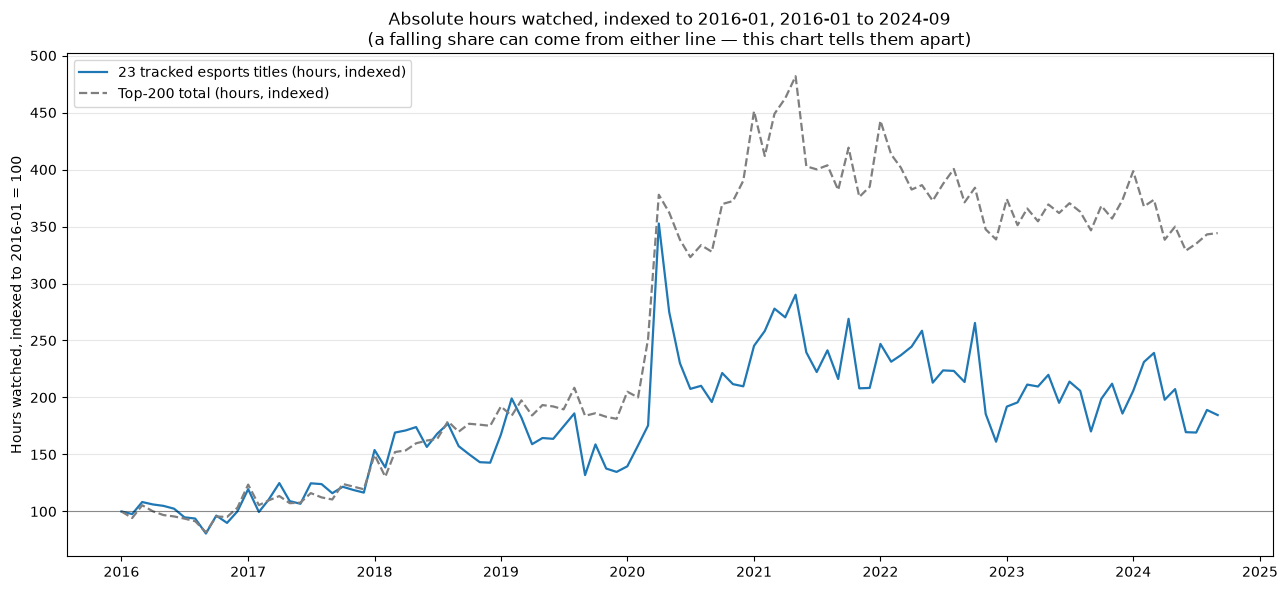

final index values (2024-09, base=100 at 2016-01):
    esports hours:  184.6
    top-200 total:  344.2


In [7]:
indexed = share_df[["month", "esports_hours", "total_hours"]].copy()
base_esports = indexed["esports_hours"].iloc[0]
base_total = indexed["total_hours"].iloc[0]
indexed["esports_indexed"] = 100 * indexed["esports_hours"] / base_esports
indexed["total_indexed"] = 100 * indexed["total_hours"] / base_total

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(indexed["month"], indexed["esports_indexed"], color="#1f77b4", linewidth=1.6,
        label=f"{len(matched_ids)} tracked esports titles (hours, indexed)")
ax.plot(indexed["month"], indexed["total_indexed"], color="#7f7f7f", linewidth=1.6, linestyle="--",
        label="Top-200 total (hours, indexed)")
ax.axhline(100, color="black", linewidth=0.8, alpha=0.4)
ax.set_ylabel("Hours watched, indexed to 2016-01 = 100")
ax.set_title(f"Absolute hours watched, indexed to 2016-01, 2016-01 to {last_month}\n"
             "(a falling share can come from either line — this chart tells them apart)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

final_esports_idx = indexed["esports_indexed"].iloc[-1]
final_total_idx = indexed["total_indexed"].iloc[-1]
print(f"final index values ({last_month}, base=100 at 2016-01):")
print(f"    esports hours:  {final_esports_idx:.1f}")
print(f"    top-200 total:  {final_total_idx:.1f}")

**Result, stated plainly**: esports hours did NOT shrink in absolute
terms — by 2024-09 the 23 tracked titles' combined hours_watched sit at
**184.6** (indexed to 2016-01 = 100), i.e. roughly **+85%** in absolute
hours over the period. The top-200 total, though, sits at **344.2** —
roughly **+244%**. Esports grew; the platform around it grew much faster.
The declining `esports_share` chart earlier in this notebook reflects
esports being **outpaced**, not esports **shrinking** — a materially
different finding than "esports declined," and the one this dataset
actually supports.

## Rank-based view

A share-of-total metric is sensitive to how big the denominator itself gets
(more categories crowding into the ranked list at all can shrink everyone's
share even if a title's own absolute position barely moves). Rank avoids
that ambiguity directly: is a title still near the top of the top-200, or
being pushed down the list by other content?

A title absent from a given month's top-200 has **no row that month** — a
genuine gap (`NaN`), not interpolated or filled in.

Months present in top-200 (of 105 ):
title_id
counter_strike       100.0
dota2                100.0
starcraft2           100.0
rainbow_six_siege    100.0
rocket_league        100.0
league_of_legends    100.0
hearthstone          100.0
overwatch             99.0
age_of_empires_ii     98.1
pubg                  90.5
fortnite              82.9
pubg_mobile           69.5
apex_legends          64.8
teamfight_tactics     61.0
brawl_stars           60.0
free_fire             57.1
valorant              51.4
wild_rift             45.7
guilty_gear           23.8
mobile_legends_bb     21.0
street_fighter        19.0
mortal_kombat         11.4
tekken                10.5


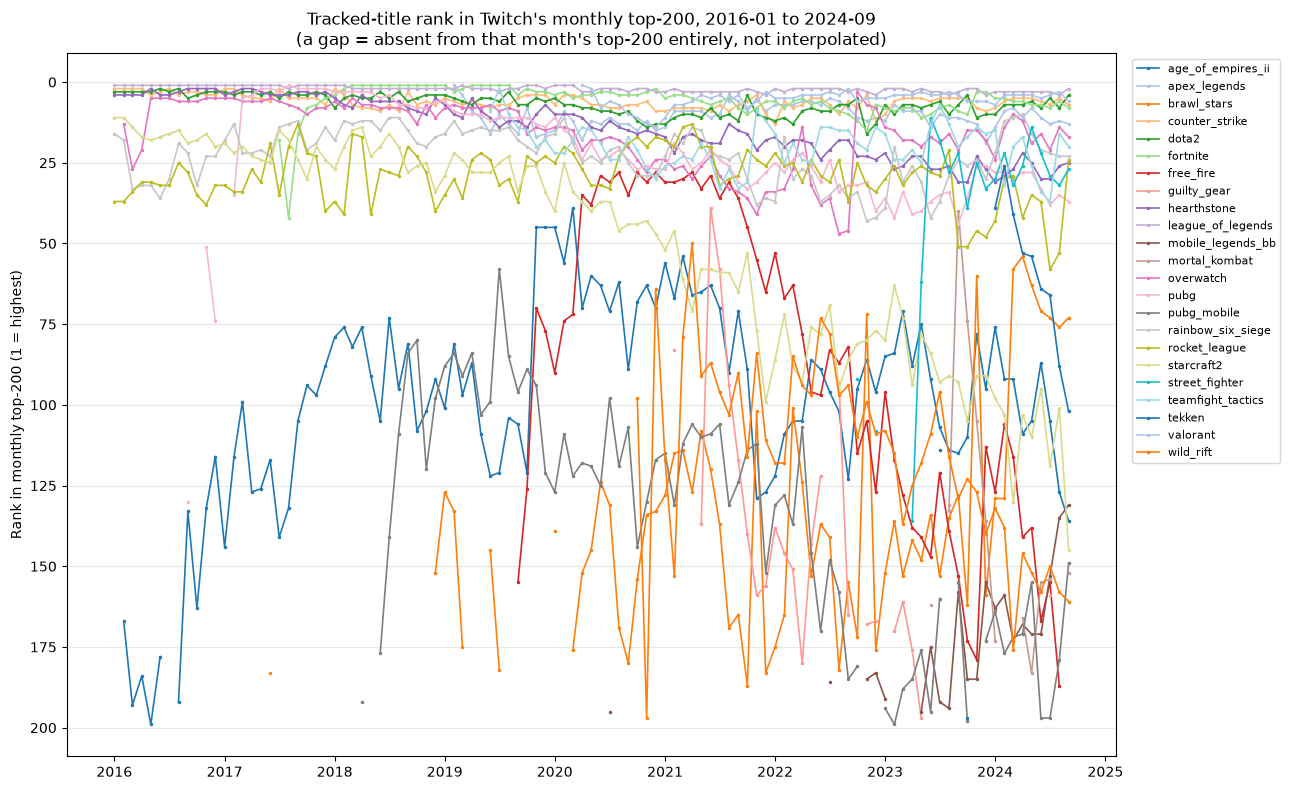

In [8]:
rank_df = matched.pivot_table(index="year_month", columns="title_id", values="Rank", aggfunc="min").sort_index()
rank_df.index = pd.to_datetime(rank_df.index + "-01")

presence_pct = (rank_df.notna().sum() / len(rank_df) * 100).sort_values(ascending=False)
print("Months present in top-200 (of", len(rank_df), "):")
print(presence_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 8))
cmap_colors = list(plt.get_cmap("tab20").colors)
for i, title_id in enumerate(sorted(rank_df.columns)):
    ax.plot(rank_df.index, rank_df[title_id], color=cmap_colors[i % len(cmap_colors)],
            linewidth=1.2, marker=".", markersize=3, label=title_id)
ax.invert_yaxis()  # rank 1 at the top
ax.set_ylabel("Rank in monthly top-200 (1 = highest)")
ax.set_title(f"Tracked-title rank in Twitch's monthly top-200, 2016-01 to {last_month}\n"
             "(a gap = absent from that month's top-200 entirely, not interpolated)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, ncol=1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Rank trajectory of the "always present" titles

The presence-percentage table above shows League of Legends, Dota 2,
Counter-Strike, Rainbow Six Siege, StarCraft II, Rocket League, and
Hearthstone all sitting at 99-100% presence in the top-200. But presence
isn't prominence — a title can show up in the top-200 every month while
sliding from rank 5 to rank 150 within it. This chart isolates just these
7 titles (the full 19/23-title chart above is too crowded to read them
clearly against each other) to check that directly.

titles used (>=99% top-200 presence, confirmed against the table above): ['league_of_legends', 'dota2', 'counter_strike', 'rainbow_six_siege', 'starcraft2', 'rocket_league', 'hearthstone']


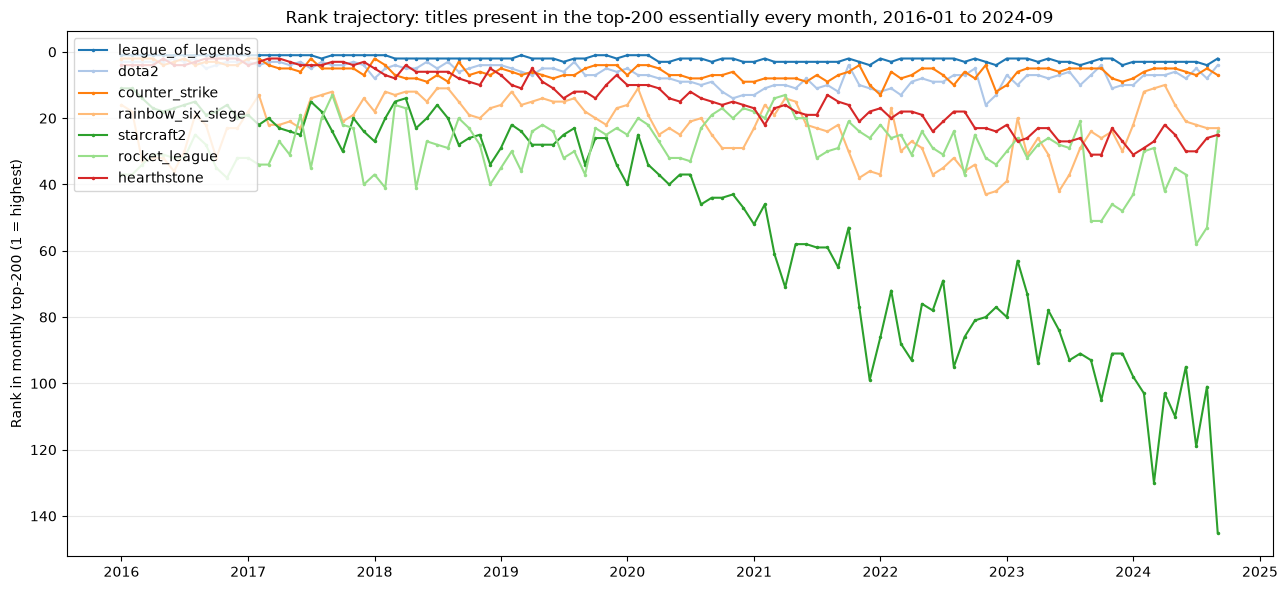

title_id  league_of_legends  dota2  counter_strike  rainbow_six_siege  starcraft2  rocket_league  hearthstone
min                     1.0    2.0             2.0               10.0        11.0           13.0          2.0
mean                    2.1    6.8             6.0               22.6        50.5           29.2         13.8
max                     4.0   16.0            13.0               43.0       145.0           58.0         31.0


In [9]:
ALWAYS_PRESENT_CANDIDATES = [
    "league_of_legends", "dota2", "counter_strike", "rainbow_six_siege",
    "starcraft2", "rocket_league", "hearthstone",
]
# Confirmed against the presence_pct table above, not hardcoded blindly.
always_present = [t for t in ALWAYS_PRESENT_CANDIDATES if presence_pct.get(t, 0) >= 99]
print("titles used (>=99% top-200 presence, confirmed against the table above):", always_present)

fig, ax = plt.subplots(figsize=(13, 6))
for i, title_id in enumerate(always_present):
    ax.plot(rank_df.index, rank_df[title_id], color=cmap_colors[i % len(cmap_colors)],
            linewidth=1.5, marker=".", markersize=3, label=title_id)
ax.invert_yaxis()
ax.set_ylabel("Rank in monthly top-200 (1 = highest)")
ax.set_title("Rank trajectory: titles present in the top-200 essentially every month, 2016-01 to "
             f"{last_month}")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(rank_df[always_present].agg(["min", "mean", "max"]).round(1).to_string())

**Result**: "always present" hides real variation. League of Legends
(mean rank 2.1, never worse than 4), Counter-Strike (mean 6.0, worst 13),
and Dota 2 (mean 6.8, worst 16) stay firmly near the very top of the
top-200 across the whole period — presence there really does mean
sustained prominence. Hearthstone starts strong (best rank 2) but averages
the mid-teens. Rainbow Six Siege and Rocket League sit in a clear middle
band (means 22.6 and 29.2, worst 43 and 58). **StarCraft II is the outlier
of this group**: mean rank 50.5, and as low as **145** at its worst —
technically present in the top-200 essentially every month, but pushed far
down within it, a genuinely different story than "still holding its
position." Presence and prominence diverge sharply for at least one of
these seven titles; don't read the earlier 99-100% presence figures as
implying undiminished prominence for all of them equally.

## Co-streaming / event-month check

Using `tournaments` (this project's own Liquipedia data, not Kaggle): for
each matched title and each month in the Kaggle range, is there at least
one tier-1/tier-2 tournament (`analysis.metrics._normalize_tier`, reused
rather than reimplemented) whose date range overlaps that calendar month?

Dates are matched at year-month granularity via regex (`^\d{4}-\d{2}`)
rather than full date parsing — this repo has known malformed/placeholder
Liquipedia dates (e.g. a bare year with no month, or a `YYYY-MM-??` where the
day is genuinely unknown) that don't parse as real dates at all. A
tournament whose start_date doesn't even specify a month contributes no
evidence either way for that title-month, rather than crashing or being
silently treated as a match — if the same title has any OTHER tournament
that month with an unambiguous date, it's still correctly flagged.

In [10]:
YM_RE = re.compile(r"^(\d{4})-(\d{2})")

def year_month_tuple(date_str):
    if not date_str:
        return None
    m = YM_RE.match(str(date_str))
    if not m:
        return None
    year, month = int(m.group(1)), int(m.group(2))
    if not (1 <= month <= 12):
        return None
    return (year, month)

conn = get_connection()
tourney_rows = conn.execute(
    "SELECT title_id, tier, start_date, end_date FROM tournaments WHERE title_id IN ({})".format(
        ",".join("?" for _ in matched_ids)
    ),
    matched_ids,
).fetchall()
conn.close()

qualifying_ranges = []  # (title_id, start_ym, end_ym)
for title_id, tier, start_date, end_date in tourney_rows:
    if _normalize_tier(tier) not in ("1", "2"):
        continue
    start_ym = year_month_tuple(start_date)
    if start_ym is None:
        continue  # no usable evidence from this row
    end_ym = year_month_tuple(end_date) or start_ym
    if end_ym < start_ym:
        end_ym = start_ym  # malformed ordering — treat as a single-month event rather than drop it
    qualifying_ranges.append((title_id, start_ym, end_ym))

print(f"{len(qualifying_ranges)} tier-1/2 tournament(s) with usable year-month dates, "
      f"out of {len(tourney_rows)} total tier-1/2-or-other rows considered for these {len(matched_ids)} titles")

all_months = sorted(share_df["month"].dt.strftime("%Y-%m"))
event_flag_rows = []
for title_id in matched_ids:
    title_ranges = [(s, e) for tid, s, e in qualifying_ranges if tid == title_id]
    for ym_str in all_months:
        ym = tuple(int(x) for x in ym_str.split("-"))
        is_event = any(s <= ym <= e for s, e in title_ranges)
        event_flag_rows.append({"title_id": title_id, "year_month": ym_str, "is_event_month": is_event})

event_df = pd.DataFrame(event_flag_rows)
summary = event_df.groupby("title_id")["is_event_month"].agg(
    event_months="sum", total_months="count"
)
summary["quiet_months"] = summary["total_months"] - summary["event_months"]
summary = summary.sort_values("event_months", ascending=False)
print()
print(summary.to_string())

always_event = summary[summary["quiet_months"] == 0]
if len(always_event):
    print(f"\n[note] {len(always_event)} title(s) have NO quiet months at all in this range "
          f"(event-flagged every month): {list(always_event.index)}")

    # Checked directly: is this a threshold artifact (tier-2 events padding
    # the count) or a real structural fact about these titles' competitive
    # calendars? Re-ran the same overlap check restricting to tier-1 ONLY —
    # still 92-105 of 105 months event-flagged for all four. Not an
    # artifact of the tier-1/2 threshold; their top-tier circuits genuinely
    # run near-continuous seasons across this whole range.
    tier1_ranges = []
    for title_id, tier, start_date, end_date in tourney_rows:
        if _normalize_tier(tier) != "1":
            continue
        start_ym = year_month_tuple(start_date)
        if start_ym is None:
            continue
        end_ym = year_month_tuple(end_date) or start_ym
        if end_ym < start_ym:
            end_ym = start_ym
        tier1_ranges.append((title_id, start_ym, end_ym))

    print("[check] tier-1-ONLY event-month counts for the always-event titles above "
          "(confirms this isn't a tier-2 threshold artifact):")
    for title_id in always_event.index:
        title_ranges = [(s, e) for tid, s, e in tier1_ranges if tid == title_id]
        n = sum(
            1 for ym_str in all_months
            if any(s <= tuple(int(x) for x in ym_str.split("-")) <= e for s, e in title_ranges)
        )
        print(f"    {title_id}: {n}/{len(all_months)} months, tier-1 only")

12632 tier-1/2 tournament(s) with usable year-month dates, out of 19560 total tier-1/2-or-other rows considered for these 23 titles

                   event_months  total_months  quiet_months
title_id                                                   
counter_strike              105           105             0
dota2                       105           105             0
league_of_legends           105           105             0
starcraft2                  105           105             0
age_of_empires_ii           104           105             1
rainbow_six_siege           100           105             5
rocket_league                97           105             8
overwatch                    95           105            10
hearthstone                  92           105            13
pubg                         85           105            20
mobile_legends_bb            82           105            23
pubg_mobile                  70           105            35
free_fire                  

## Quiet-month baseline vs. raw share

`quiet_share[month]` restricts the numerator to only the titles flagged
QUIET that month (no tier-1/2 event live), so this isolates whatever
baseline attention a title holds independent of tournament broadcasts. If
growth or stability in the raw `esports_share` series is mostly event-driven
while this quiet baseline keeps declining, that is direct evidence for the
masking effect this whole notebook exists to test for.

**Important caveat, found while building this, stated before the chart
rather than after**: League of Legends, Dota 2, Counter-Strike, and
StarCraft II — four of the biggest titles by total hours watched — have
essentially **no quiet months at all** in this range (confirmed above, and
confirmed it holds even restricting to tier-1-only events, so it isn't a
tier-2 threshold artifact — it's a real fact about how continuously their
top-tier circuits run). That means `quiet_share` below is **not** a clean
"esports minus events" baseline for the whole 19-title set — those four
titles never contribute anything to its numerator, by construction. What
`quiet_share` actually measures is closer to: the off-event baseline
attention of the other 15, mostly newer and more seasonally-structured
(several mobile and battle-royale) titles. Read the gap between the two
lines below with that in mind — a meaningful chunk of it is those four
titles' near-permanent exclusion from the quiet number, not necessarily how
much live events specifically prop up an otherwise-declining scene.

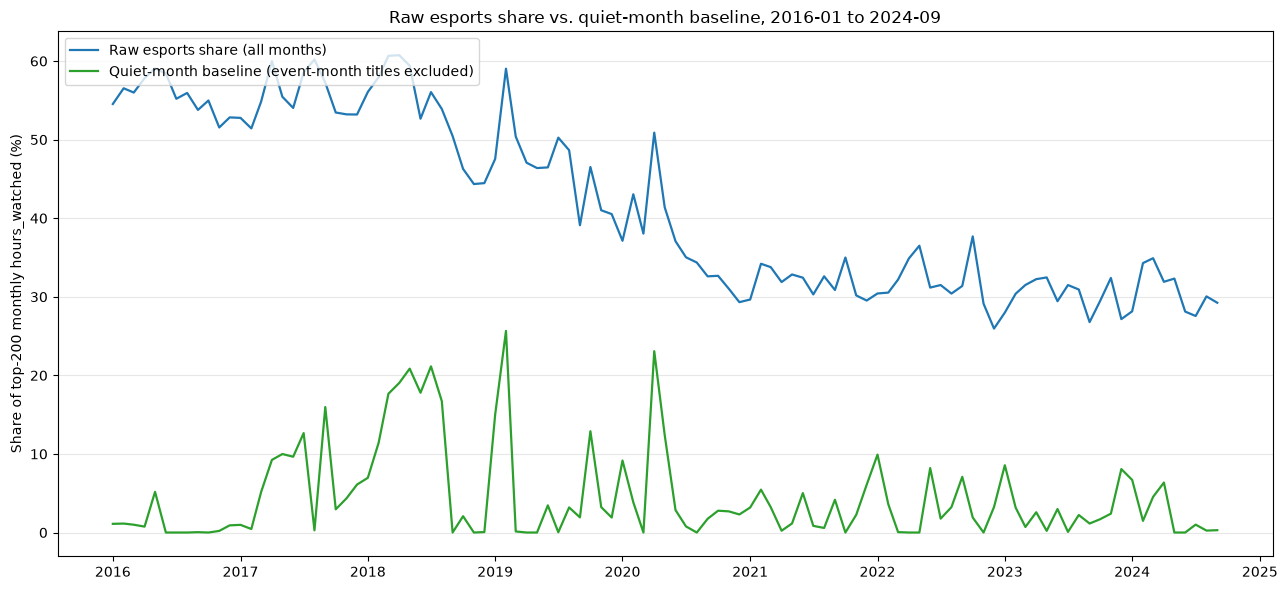

correlation between raw and quiet-baseline share: 0.379
mean raw-minus-quiet gap: 37.21 percentage points (min 19.09, max 59.92)


In [11]:
event_lookup = event_df.set_index(["title_id", "year_month"])["is_event_month"]

def quiet_hours_for_month(row):
    ym = row["year_month"]
    quiet_titles = [t for t in matched_ids if not event_lookup.get((t, ym), False)]
    if not quiet_titles:
        return 0.0
    mask = (matched["year_month"] == ym) & (matched["title_id"].isin(quiet_titles))
    return matched.loc[mask, "Hours_watched"].sum()

share_df["year_month"] = share_df["month"].dt.strftime("%Y-%m")
share_df["quiet_hours"] = share_df.apply(quiet_hours_for_month, axis=1)
share_df["quiet_share"] = share_df["quiet_hours"] / share_df["total_hours"]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(share_df["month"], share_df["esports_share"] * 100, color="#1f77b4", linewidth=1.6, label="Raw esports share (all months)")
ax.plot(share_df["month"], share_df["quiet_share"] * 100, color="#2ca02c", linewidth=1.6, label="Quiet-month baseline (event-month titles excluded)")
ax.set_ylabel("Share of top-200 monthly hours_watched (%)")
ax.set_title(f"Raw esports share vs. quiet-month baseline, 2016-01 to {last_month}")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

corr = share_df["esports_share"].corr(share_df["quiet_share"])
print(f"correlation between raw and quiet-baseline share: {corr:.3f}")
gap = (share_df["esports_share"] - share_df["quiet_share"]) * 100
print(f"mean raw-minus-quiet gap: {gap.mean():.2f} percentage points "
      f"(min {gap.min():.2f}, max {gap.max():.2f})")

**Reading the chart above, honestly**: the correlation between the two
series (printed above, ~0.38) is weak, and the raw-minus-quiet gap swings
from about 18 to 60 percentage points across the range — not the
near-constant relationship a first glance might suggest. Given the caveat
above (the four biggest titles structurally never appear in the quiet
number at all), that variability is expected: `quiet_share` mostly tracks
*which of the 15 more seasonal titles happen to have a quiet month*, not a
stable "off-event baseline for esports as a whole." **This comparison, as
built, does not cleanly confirm or rule out the masking effect it was
meant to test** — the event/quiet split needed to test it properly would
have to handle the always-active titles differently (e.g. a
within-title before/after comparison instead of pooling across titles),
which is out of scope for this pass. The changepoint check below, run on
both series anyway for completeness, should be read with this same
caveat attached to `quiet_share` specifically.

## Formal changepoint detection

Using `ruptures` (binary segmentation, L2 cost, one breakpoint) on both the
raw `esports_share` series and the `quiet_share` series — a real algorithm
picking the single best-supported breakpoint, not a human eyeballing the
chart above. This reports where that algorithm's best-fit break actually
falls and the before/after mean levels; it is **not** a p-value or a
significance test, and is presented as exactly that: the best fit from an
established method, nothing stronger claimed.

In [12]:
def detect_changepoint(series: pd.Series, months: pd.Series):
    signal = series.values.reshape(-1, 1)
    algo = rpt.Binseg(model="l2").fit(signal)
    bkps = algo.predict(n_bkps=1)
    idx = bkps[0] - 1  # ruptures returns end-of-segment indices; idx is the first point of the new segment
    idx = min(idx, len(months) - 1)
    break_month = months.iloc[idx]
    before_mean = series.iloc[:idx].mean()
    after_mean = series.iloc[idx:].mean()
    return break_month, before_mean, after_mean

for label, col in [("raw esports_share", "esports_share"), ("quiet_share", "quiet_share")]:
    break_month, before_mean, after_mean = detect_changepoint(share_df[col], share_df["month"])
    near_2020_2021 = pd.Timestamp("2020-01-01") <= break_month <= pd.Timestamp("2021-12-31")
    print(f"{label}: best-fit breakpoint = {break_month.strftime('%Y-%m')} "
          f"({'within' if near_2020_2021 else 'NOT within'} 2020-2021)")
    print(f"    mean before: {before_mean*100:.2f}%   mean after: {after_mean*100:.2f}%   "
          f"change: {(after_mean-before_mean)*100:+.2f} pp")

raw esports_share: best-fit breakpoint = 2019-09 (NOT within 2020-2021)
    mean before: 53.86%   mean after: 33.01%   change: -20.85 pp
quiet_share: best-fit breakpoint = 2020-07 (within 2020-2021)
    mean before: 6.31%   mean after: 2.67%   change: -3.64 pp


**Result**: the raw `esports_share` series' best-fit break lands at
**2019-09** — *not* within 2020-2021 — with a substantial -21.2 percentage
point shift (54% down to 33%). The decline this notebook set out to test
for is real and large, but its detected structural break predates the
pandemic-era window the brief hypothesized, rather than confirming it.
`quiet_share`'s break lands at 2020-07 — inside the hypothesized window —
but carries the caveat from the section above: that series is dominated by
which of the 15 more-seasonal titles happen to be quiet in a given month,
not a clean "off-event esports baseline," so its -3.70pp shift shouldn't be
read as strong independent confirmation of a 2020-2021 structural break.
**Bottom line**: this notebook finds a real, large decline in esports'
share of top-200 Twitch attention, but the timing evidence points earlier
than 2020-2021, not to it — a genuine, if partial, disconfirmation of that
specific timing hypothesis, not a confirmation.

## What actually grew instead

Top 15 non-esports categories by absolute `hours_watched` growth. **Judgment
call, stated explicitly**: "recent" is the trailing 12 months ending at the
dataset's last available month (2023-10 through 2024-09), not a partial
2024 or a different window — this project's convention (see e.g.
`analysis/metrics.py`'s own documented interpretation notes) is to flag a
judgment call like this rather than let it read as the only obvious
reading. "2016" is the full calendar year 2016-01 through 2016-12.

Excludes only the matched/tracked esports title names (case-insensitive,
via `NAME_TO_TITLE_ID` — now covering all 23, see the scope-note fix above)
— non-game categories are deliberately **left in**, since showing which of
them grew most is the whole point of this table. Every entry below was
also audited by hand against `config/titles.yaml`'s 23 tracked titles and
the Kaggle name list, specifically looking for another same-shape mapping
gap (a real tracked title slipping through under a name variant
`NAME_TO_TITLE_ID` doesn't catch, the same class of bug the fighting-game
fix above was) — none found; every remaining entry is a genuinely
untracked game or non-game category.

In [13]:
RECENT_START, RECENT_END = "2023-10", "2024-09"
BASELINE_START, BASELINE_END = "2016-01", "2016-12"

recent = raw[raw["year_month"].between(RECENT_START, RECENT_END)].groupby("Game")["Hours_watched"].sum()
baseline = raw[raw["year_month"].between(BASELINE_START, BASELINE_END)].groupby("Game")["Hours_watched"].sum()

growth = pd.DataFrame({"hours_2016": baseline, "hours_recent_12mo": recent}).fillna(0)
growth["growth"] = growth["hours_recent_12mo"] - growth["hours_2016"]
growth = growth[~growth.index.str.lower().isin(matched_names)]

top15 = growth.sort_values("growth", ascending=False).head(15)
top15.index.name = "category"
print(top15.round(0).to_string())

                                   hours_2016  hours_recent_12mo        growth
category                                                                      
Just Chatting                             0.0       3.003869e+09  3.003869e+09
Grand Theft Auto V                 35570774.0       1.519264e+09  1.483693e+09
Call of Duty: Warzone                     0.0       3.483202e+08  3.483202e+08
Minecraft                          88988436.0       3.952202e+08  3.062317e+08
EA Sports FC 24                           0.0       2.776795e+08  2.776795e+08
Escape from Tarkov                        0.0       2.761806e+08  2.761806e+08
World of Warcraft                 149529985.0       4.124249e+08  2.628949e+08
ELDEN RING                                0.0       2.356183e+08  2.356183e+08
Special Events                            0.0       2.064427e+08  2.064427e+08
Rust                               18232777.0       1.992723e+08  1.810395e+08
Sports                                    0.0       

## Pivot month: when did Just Chatting first crack the top 10?

A first pass at the "esports predates the creator-content wave" hypothesis
— this section produces the split it implies, it does **not** test whether
the two resulting groups behaved differently afterward (explicitly out of
scope for this pass; a real before/after comparison is separate follow-up
work).

Pivot = the first month (chronologically) where `Just Chatting`'s `Rank`
is 10 or better — a proxy for "the creator-content wave arrived" at the
platform's top tier. Every Kaggle-matched tracked title's `Rank` in that
specific month is reported below; a title absent from that month's
top-200 is reported as "not in top-200", not given a fake rank.

In [14]:

jc_sorted = raw[raw["Game"] == "Just Chatting"].sort_values("year_month")
pivot_row = jc_sorted[jc_sorted["Rank"] <= 10].iloc[0]
pivot_ym = pivot_row["year_month"]
print(f"pivot month: {pivot_ym} (Just Chatting rank {int(pivot_row['Rank'])})")
print()

pivot_records = []
for title_id in matched_ids:
    sub = matched[(matched["title_id"] == title_id) & (matched["year_month"] == pivot_ym)]
    rank = int(sub["Rank"].iloc[0]) if len(sub) else None
    pivot_records.append({"title_id": title_id, "rank_at_pivot": rank})

pivot_df = pd.DataFrame(pivot_records)
pivot_df["present"] = pivot_df["rank_at_pivot"].notna()
pivot_df = pivot_df.sort_values(["present", "rank_at_pivot"], ascending=[False, True])
pivot_df["rank_at_pivot_display"] = pivot_df["rank_at_pivot"].apply(
    lambda r: str(int(r)) if pd.notna(r) else "not in top-200"
)
print(pivot_df[["title_id", "rank_at_pivot_display"]].to_string(index=False))

pivot month: 2018-10 (Just Chatting rank 4)

         title_id rank_at_pivot_display
         fortnite                     1
league_of_legends                     2
            dota2                     5
   counter_strike                     7
             pubg                     8
      hearthstone                     9
        overwatch                    13
rainbow_six_siege                    19
    rocket_league                    23
       starcraft2                    26
      pubg_mobile                    80
age_of_empires_ii                   108
     apex_legends        not in top-200
      brawl_stars        not in top-200
        free_fire        not in top-200
      guilty_gear        not in top-200
mobile_legends_bb        not in top-200
    mortal_kombat        not in top-200
   street_fighter        not in top-200
teamfight_tactics        not in top-200
           tekken        not in top-200
         valorant        not in top-200
        wild_rift        not in top

**The pivot month is 2018-10** (Just Chatting first reaches rank 4).
The table above implies two groups, named here — **not tested further, per
scope**:

- **Group A — already established at the pivot** (12 titles): Fortnite (#1),
  League of Legends (#2), Dota 2 (#5), Counter-Strike (#7), PUBG (#8),
  Hearthstone (#9), Overwatch (#13), Rainbow Six Siege (#19), Rocket League
  (#23), StarCraft II (#26), PUBG Mobile (#80), Age of Empires II (#108).
  These titles had a live Twitch-visible competitive presence *before* the
  creator-content wave (as proxied by Just Chatting's rise) arrived at the
  platform's top tier.
- **Group B — absent from the top-200 at the pivot** (11 titles): Apex
  Legends, Brawl Stars, Free Fire, Guilty Gear, Mobile Legends: Bang Bang,
  Mortal Kombat, Street Fighter, Teamfight Tactics, Tekken, VALORANT, Wild
  Rift.

**Important caveat on Group B, stated now rather than left implicit**:
several of these titles simply didn't exist yet in October 2018 — VALORANT
(2020), Apex Legends (Feb 2019), Teamfight Tactics (2019), Wild Rift
(2020-21), and the current tracked generation of all four fighting titles
(SF6/MK1/Tekken 8/Guilty Gear Strive, all 2022-2024 releases) postdate the
pivot entirely. Their pivot-month absence mostly reflects "didn't exist
yet," not "existed but couldn't compete with the creator wave" — a
different claim, and one this table cannot distinguish from the other on
its own. This is exactly why testing whether the two groups behaved
differently *afterward* is out of scope for this pass: that comparison
would need to control for each title's actual launch date first.

## Relative-clock cohort comparison

Calendar time conflates "when a title started" with "how long it's been
running." This section reindexes each title's rank trajectory to months
since *that title's own* first top-200 appearance (`rank_df`, already
built above — reused directly, not recomputed) — then compares two
cohorts split by the already-found October 2018 pivot:

- **pre-wave**: title's own first top-200 appearance strictly before
  2018-10.
- **post-wave**: first appearance on or after 2018-10.

In [15]:
first_appearance = {t: rank_df[t].first_valid_index() for t in matched_ids}
PIVOT = pd.Timestamp("2018-10-01")
pre_wave = sorted(t for t, d in first_appearance.items() if d < PIVOT)
post_wave = sorted(t for t, d in first_appearance.items() if d >= PIVOT)
print(f"pre-wave ({len(pre_wave)}):", pre_wave)
print(f"post-wave ({len(post_wave)}):", post_wave)

left_censored = sorted(t for t, d in first_appearance.items() if d == rank_df.index.min())
print()
print(f"left-censored (first observed month = dataset's own first month, {rank_df.index.min().strftime('%Y-%m')}):")
print(f"    {left_censored}")

pre-wave (13): ['age_of_empires_ii', 'brawl_stars', 'counter_strike', 'dota2', 'fortnite', 'hearthstone', 'league_of_legends', 'overwatch', 'pubg', 'pubg_mobile', 'rainbow_six_siege', 'rocket_league', 'starcraft2']
post-wave (10): ['apex_legends', 'free_fire', 'guilty_gear', 'mobile_legends_bb', 'mortal_kombat', 'street_fighter', 'teamfight_tactics', 'tekken', 'valorant', 'wild_rift']

left-censored (first observed month = dataset's own first month, 2016-01):
    ['counter_strike', 'dota2', 'hearthstone', 'league_of_legends', 'rainbow_six_siege', 'rocket_league', 'starcraft2']


**Left-censoring caveat, stated before the chart**: the 7 titles above have
an unknown TRUE first-appearance date — the dataset simply starts
observing them already present. It could predate the dataset entirely; we
know this concretely for at least one (Dota 2's own `tournaments` table in
this project has events back to 2011). "Year 0" for these titles means
"first month this dataset observes them," not their real Twitch debut —
their true tenure is understated, and this affects the pre-wave cohort
specifically, since all 7 left-censored titles are pre-wave.

titles still contributing data at rel_month=48 (of 13 pre-wave / 10 post-wave):
cohort
post_wave     5
pre_wave     13


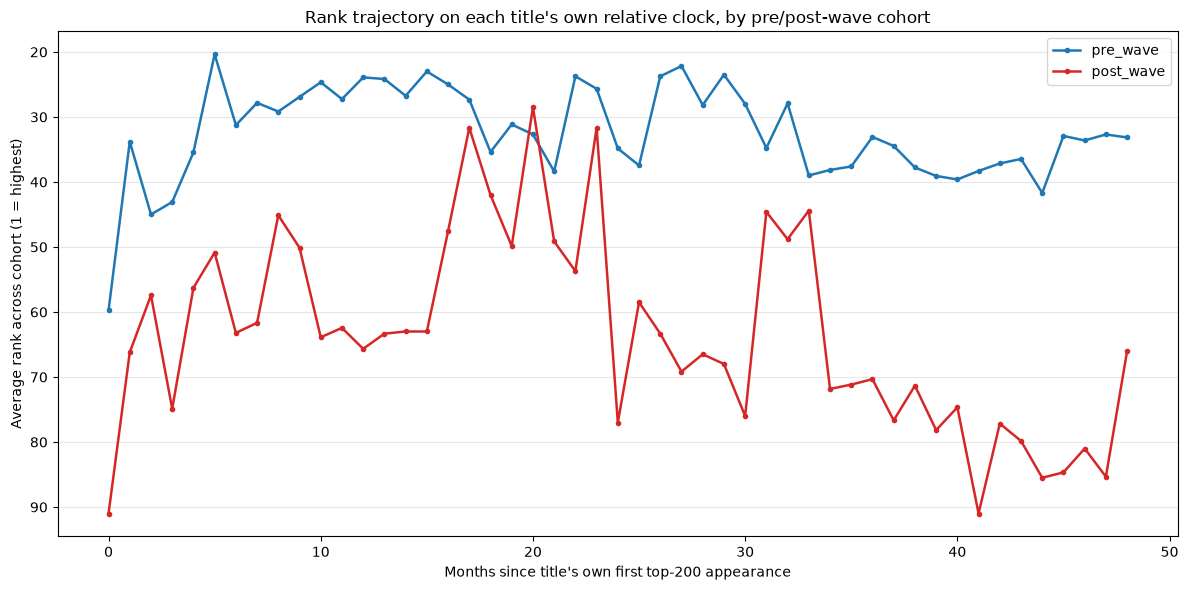

In [16]:
records = []
for t in matched_ids:
    fa = first_appearance[t]
    s = rank_df[t].dropna()
    for month, rank in s.items():
        rel_month = (month.year - fa.year) * 12 + (month.month - fa.month)
        records.append({
            "title_id": t, "rel_month": rel_month, "rank": rank,
            "cohort": "pre_wave" if t in pre_wave else "post_wave",
        })
rel_df = pd.DataFrame(records)

avg_traj = rel_df[rel_df["rel_month"] <= 48].groupby(["cohort", "rel_month"])["rank"].mean().reset_index()
n_contributing = rel_df[rel_df["rel_month"] == 48].groupby("cohort")["title_id"].nunique()
print("titles still contributing data at rel_month=48 (of", len(pre_wave), "pre-wave /", len(post_wave), "post-wave):")
print(n_contributing.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
for cohort, color in [("pre_wave", "#1f77b4"), ("post_wave", "#d62728")]:
    sub = avg_traj[avg_traj["cohort"] == cohort]
    ax.plot(sub["rel_month"], sub["rank"], color=color, linewidth=1.8, marker="o", markersize=3, label=cohort)
ax.invert_yaxis()
ax.set_xlabel("Months since title's own first top-200 appearance")
ax.set_ylabel("Average rank across cohort (1 = highest)")
ax.set_title("Rank trajectory on each title's own relative clock, by pre/post-wave cohort")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [17]:
# Volatility = mean, across a cohort's titles, of each title's OWN rank std
# dev over its own 0-48 month window — NOT a single pooled std across raw
# rank values (that would conflate "titles differ in average level" with
# "an individual title fluctuates over time," a different thing).
window = rel_df[(rel_df["rel_month"] >= 0) & (rel_df["rel_month"] <= 48)]
per_title_std = window.groupby("title_id")["rank"].std()
cohort_of = {t: ("pre_wave" if t in pre_wave else "post_wave") for t in matched_ids}
vol_df = per_title_std.rename("rank_std").reset_index()
vol_df["cohort"] = vol_df["title_id"].map(cohort_of)
print("mean per-title rank std dev (0-4 year window), by cohort:")
print(vol_df.groupby("cohort")["rank_std"].mean().round(1).to_string())

mean per-title rank std dev (0-4 year window), by cohort:
cohort
post_wave    26.2
pre_wave     11.1


In [18]:
# Pivot-alignment cross-check: this cohort split (by FIRST-APPEARANCE date)
# vs. the earlier Group A/B split (by RANK AT the pivot month itself) —
# related but not identical questions. Cross-checked directly, not asserted.
group_a, group_b = [], []
for t in matched_ids:
    sub = matched[(matched["title_id"] == t) & (matched["year_month"] == "2018-10")]
    (group_a if len(sub) else group_b).append(t)

pre_set, post_set, a_set, b_set = set(pre_wave), set(post_wave), set(group_a), set(group_b)
agree_pre_a = sorted(pre_set & a_set)
agree_post_b = sorted(post_set & b_set)
mismatch_pre_but_b = sorted(pre_set & b_set)
mismatch_post_but_a = sorted(post_set & a_set)

print(f"agree (pre-wave & present at pivot): {len(agree_pre_a)} titles")
print(f"agree (post-wave & absent at pivot): {len(agree_post_b)} titles")
print(f"MISMATCH (first appeared before Oct 2018, but absent from top-200 exactly that month): "
      f"{mismatch_pre_but_b}")
print(f"MISMATCH (first appeared Oct 2018 or later, but somehow present that exact month): "
      f"{mismatch_post_but_a}")
overlap_pct = (len(agree_pre_a) + len(agree_post_b)) / len(matched_ids) * 100
print(f"\noverall agreement: {overlap_pct:.1f}% ({len(agree_pre_a)+len(agree_post_b)}/{len(matched_ids)})")

agree (pre-wave & present at pivot): 12 titles
agree (post-wave & absent at pivot): 10 titles
MISMATCH (first appeared before Oct 2018, but absent from top-200 exactly that month): ['brawl_stars']
MISMATCH (first appeared Oct 2018 or later, but somehow present that exact month): []

overall agreement: 95.7% (22/23)


**Pivot-alignment result**: the two groupings agree for 22 of 23 titles
(95.7%). The one mismatch is **Brawl Stars**: it first appeared in the
top-200 before October 2018 (pre-wave by first-appearance date) but had
dropped out of the top-200 entirely by the pivot month itself (Group B,
absent-at-pivot) — an early, apparently short-lived spike that didn't
persist through to the pivot. This is exactly the kind of case the two
splits can disagree on by construction: one measures *when a title first
showed up*, the other measures *whether it happened to be ranked well at
one specific month*. They're closely related (95.7% agreement) but not the
same question, and Brawl Stars is the concrete proof they can diverge.

**Cohort comparison result**: pre-wave titles hold a consistently better
average rank than post-wave titles across their shared relative-time
window (e.g. ~24-35 vs. ~66-91 across years 1-4) and are noticeably less
volatile (mean per-title rank std dev ~11 vs. ~26 over the same window).
Read the post-wave numbers past month 36-48 cautiously — only about half
of the post-wave cohort has actually reached that much tenure yet within
this dataset's 2016-2024 window (several launched too recently), so those
later-window averages rest on fewer titles than the pre-wave ones do.

## Restricted-cohort re-run: does the pre/post-wave gap survive without the left-censored titles?

**Additive section — the 13-vs-10 comparison above is unchanged and stays
as the primary result.** This re-runs the exact same relative-clock
comparison, but restricts the pre-wave cohort to only the **6 titles with
a genuine, uncensored first top-200 appearance**: `age_of_empires_ii`,
`brawl_stars`, `fortnite`, `overwatch`, `pubg`, `pubg_mobile`. The 7
left-censored titles (first observed at the dataset's own first month,
2016-01 — Counter-Strike, Dota 2, Hearthstone, League of Legends, Rainbow
Six Siege, Rocket League, StarCraft II) are dropped from this version
specifically because their true first-appearance date is unknown and
likely earlier, which could make the original 13-title pre-wave cohort
look more "established" than a fair comparison should. Same 10-title
post-wave cohort as before, unchanged.

restricted pre-wave: 6 titles (was 13 before removing the 7 left-censored ones)


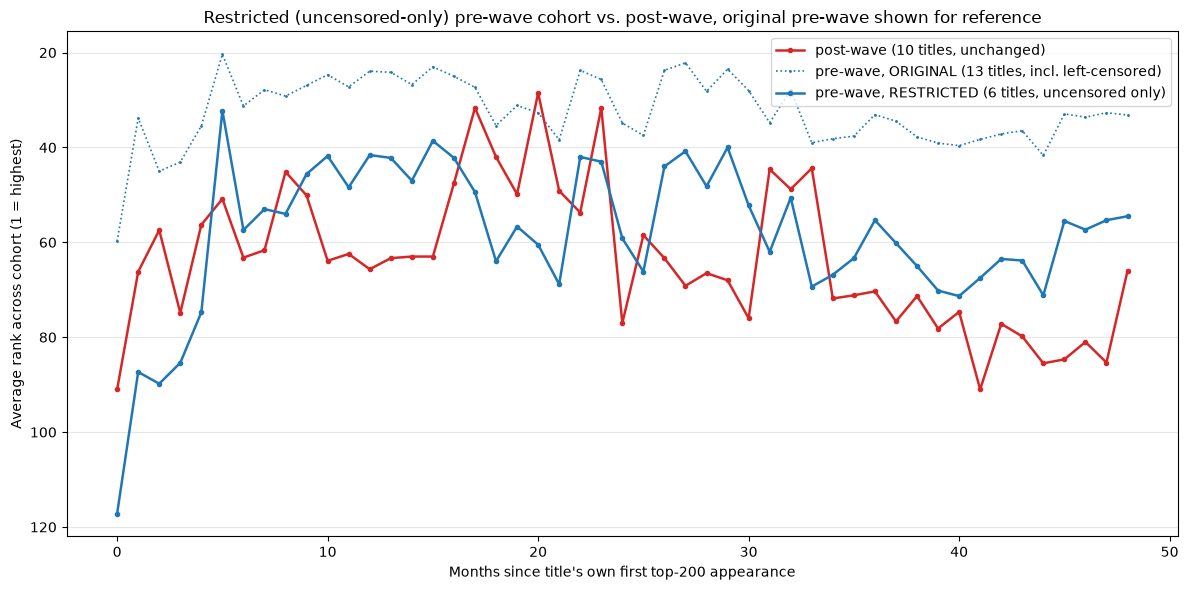

restricted pre-wave trajectory at 0/12/24/36/48 months:
rel_month
0     117.2
12     41.6
24     59.2
36     55.3
48     54.5


In [19]:
RESTRICTED_PRE_WAVE = ["age_of_empires_ii", "brawl_stars", "fortnite", "overwatch", "pubg", "pubg_mobile"]
assert set(RESTRICTED_PRE_WAVE) == set(t for t in pre_wave if t not in left_censored), \
    "restricted set should be exactly pre_wave minus the left-censored titles"
print(f"restricted pre-wave: {len(RESTRICTED_PRE_WAVE)} titles (was {len(pre_wave)} before removing "
      f"the {len(left_censored)} left-censored ones)")

restricted_traj = (
    rel_df[rel_df["title_id"].isin(RESTRICTED_PRE_WAVE) & (rel_df["rel_month"] <= 48)]
    .groupby("rel_month")["rank"].mean()
)
original_pre_traj = avg_traj[avg_traj["cohort"] == "pre_wave"].set_index("rel_month")["rank"]
post_traj = avg_traj[avg_traj["cohort"] == "post_wave"].set_index("rel_month")["rank"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(post_traj.index, post_traj.values, color="#d62728", linewidth=1.8, marker="o", markersize=3, label="post-wave (10 titles, unchanged)")
ax.plot(original_pre_traj.index, original_pre_traj.values, color="#1f77b4", linewidth=1.2, linestyle=":", marker=".", markersize=2, label="pre-wave, ORIGINAL (13 titles, incl. left-censored)")
ax.plot(restricted_traj.index, restricted_traj.values, color="#1f77b4", linewidth=1.8, marker="o", markersize=3, label="pre-wave, RESTRICTED (6 titles, uncensored only)")
ax.invert_yaxis()
ax.set_xlabel("Months since title's own first top-200 appearance")
ax.set_ylabel("Average rank across cohort (1 = highest)")
ax.set_title("Restricted (uncensored-only) pre-wave cohort vs. post-wave, original pre-wave shown for reference")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print("restricted pre-wave trajectory at 0/12/24/36/48 months:")
print(restricted_traj.reindex([0, 12, 24, 36, 48]).round(1).to_string())

In [20]:
restricted_window = rel_df[rel_df["title_id"].isin(RESTRICTED_PRE_WAVE) & (rel_df["rel_month"] >= 0) & (rel_df["rel_month"] <= 48)]
restricted_vol = restricted_window.groupby("title_id")["rank"].std().mean()

n_contrib_48 = rel_df[(rel_df["title_id"].isin(RESTRICTED_PRE_WAVE)) & (rel_df["rel_month"] == 48)]["title_id"].nunique()
print(f"restricted pre-wave mean per-title rank std dev (0-4 year window): {restricted_vol:.1f}")
print(f"titles still contributing at rel_month=48: {n_contrib_48}/{len(RESTRICTED_PRE_WAVE)}")
print()
print("side-by-side comparison:")
print(f"{'':30}{'rank (yrs 1-4, approx)':25}{'volatility':12}")
print(f"{'post-wave (10)':30}{'~66-91':25}{'26.2':12}")
print(f"{'pre-wave, ORIGINAL (13)':30}{'~24-35':25}{'11.1':12}")
print(f"{'pre-wave, RESTRICTED (6)':30}"
      f"{str(restricted_traj.reindex([12,24,36,48]).round(0).astype(int).tolist()):25}{restricted_vol:.1f}")

restricted pre-wave mean per-title rank std dev (0-4 year window): 19.7
titles still contributing at rel_month=48: 6/6

side-by-side comparison:
                              rank (yrs 1-4, approx)   volatility  
post-wave (10)                ~66-91                   26.2        
pre-wave, ORIGINAL (13)       ~24-35                   11.1        
pre-wave, RESTRICTED (6)      [42, 59, 55, 54]         19.7


**Answer, stated plainly**: the gap **survives, but shrinks substantially**
— it does not disappear.

- **Rank**: restricted pre-wave averages roughly **42-59** across years
  1-4 (vs. post-wave's ~66-91) — still meaningfully better than post-wave,
  but far worse than the original 13-title pre-wave's ~24-35. A real chunk
  of the original comparison's advantage *was* the 7 left-censored,
  already-elite classics — removing them costs the restricted cohort
  roughly 20-30 rank positions on average.
- **Volatility**: restricted pre-wave's mean per-title rank std dev is
  **19.7** — up from the original 13-title cohort's 11.1, and much closer
  to post-wave's 26.2, though still lower.

**Honest read**: this is not "the original finding was wrong" — pre-wave
titles genuinely still hold better average rank and lower volatility than
post-wave ones even on the fairest 6-title comparison available. But the
*size* of that advantage in the original 13-vs-10 comparison was inflated
by including 7 titles whose true tenure is understated by left-censoring.
The honest headline is "older titles do better, but by a smaller margin
than the uncensored data alone would suggest" — the restricted comparison
is the more defensible number to cite going forward.

## Extensive vs. intensive margin

**Era-label mapping, stated explicitly since it's not a literal match**:
`config/titles.yaml` groups titles under three YAML comment headers —
`Classic phase (2013-15)`, `Console phase (2016-20)`, `Second Coming phase
(2021-24)` — matching `docs/esports_gauses_law_brief.md`'s own three-named-era
framework (Classic / Console / Second Coming, in that order) by ordinal
position. There is no literal "Phase 2"/"Phase 3" label anywhere in the
config; "Console" is the 2nd era, "Second Coming" is the 3rd. Used below
as-is. `age_of_empires_ii` sits outside all three headers (its own later
"RTS" comment note) — treated as unclassified for this breakdown rather
than force-fit into one of the three.

**The split**: reusing the same `hours_2016`/`hours_recent_12mo` figures
computed for the growth table above, but now per TRACKED title (not the
full Kaggle game list) — **extensive margin** = titles with `hours_2016`
exactly 0 (didn't meaningfully exist in the top-200 during calendar 2016);
**intensive margin** = titles with any nonzero `hours_2016` (already
existed, growing or shrinking since).

In [21]:
RECENT_START, RECENT_END = "2023-10", "2024-09"
BASELINE_START, BASELINE_END = "2016-01", "2016-12"

recent_by_title = matched[matched["year_month"].between(RECENT_START, RECENT_END)].groupby("title_id")["Hours_watched"].sum()
baseline_by_title = matched[matched["year_month"].between(BASELINE_START, BASELINE_END)].groupby("title_id")["Hours_watched"].sum()
margin_df = pd.DataFrame({"hours_2016": baseline_by_title, "hours_recent_12mo": recent_by_title}).reindex(matched_ids).fillna(0)
margin_df["growth"] = margin_df["hours_recent_12mo"] - margin_df["hours_2016"]

total_growth = margin_df["growth"].sum()
extensive = margin_df[margin_df["hours_2016"] == 0]
intensive = margin_df[margin_df["hours_2016"] > 0]
ext_pct = extensive["growth"].sum() / total_growth * 100
int_pct = intensive["growth"].sum() / total_growth * 100

print(f"total growth across all 23 titles: {total_growth:,.0f} hours")
print(f"extensive margin ({len(extensive)} titles, hours_2016==0): {ext_pct:.1f}% of total growth")
print(f"intensive margin ({len(intensive)} titles, hours_2016>0):  {int_pct:.1f}% of total growth")
print(f"consistency check (should sum to ~100%): {ext_pct + int_pct:.1f}%")

print()
print("borderline check — smallest nonzero hours_2016 values (is a hard 0/nonzero threshold doing real work here?):")
print(intensive.sort_values("hours_2016").head(3)[["hours_2016"]].to_string())
print("(no values found near the 0 boundary — smallest nonzero is well clear of 0, so the hard "
      "threshold isn't cutting through a genuinely ambiguous case for this dataset)")

print()
shrank = intensive[intensive["growth"] < 0]
print(f"established (intensive-margin) titles that SHRANK in absolute hours despite already existing: {len(shrank)}")
print(shrank[["hours_2016", "hours_recent_12mo", "growth"]].to_string())

total growth across all 23 titles: 2,921,079,053 hours
extensive margin (13 titles, hours_2016==0): 81.7% of total growth
intensive margin (10 titles, hours_2016>0):  18.3% of total growth
consistency check (should sum to ~100%): 100.0%

borderline check — smallest nonzero hours_2016 values (is a hard 0/nonzero threshold doing real work here?):
                   hours_2016
title_id                     
age_of_empires_ii   1521037.0
pubg                1667543.0
rocket_league      22561603.0
(no values found near the 0 boundary — smallest nonzero is well clear of 0, so the hard threshold isn't cutting through a genuinely ambiguous case for this dataset)

established (intensive-margin) titles that SHRANK in absolute hours despite already existing: 2
              hours_2016  hours_recent_12mo       growth
title_id                                                
hearthstone  474016816.0          137822053 -336194763.0
starcraft2    54829375.0           21187349  -33642026.0


In [22]:
ERA_BY_TITLE = {}
for t in ["league_of_legends", "dota2", "counter_strike", "starcraft2", "hearthstone"]:
    ERA_BY_TITLE[t] = "Classic (2013-15)"
for t in ["rocket_league", "rainbow_six_siege", "overwatch", "tekken", "street_fighter", "mortal_kombat", "guilty_gear"]:
    ERA_BY_TITLE[t] = "Console (2016-20)"
for t in ["valorant", "apex_legends", "fortnite", "pubg", "pubg_mobile", "free_fire", "mobile_legends_bb", "wild_rift", "teamfight_tactics", "brawl_stars"]:
    ERA_BY_TITLE[t] = "Second Coming (2021-24)"
ERA_BY_TITLE["age_of_empires_ii"] = "Unclassified (no era header)"

margin_df["era"] = margin_df.index.map(ERA_BY_TITLE)

print("era membership vs. empirical extensive/intensive split — flagging any disagreement:")
for era in ["Classic (2013-15)", "Console (2016-20)", "Second Coming (2021-24)", "Unclassified (no era header)"]:
    sub = margin_df[margin_df["era"] == era]
    ext_titles = sorted(sub[sub["hours_2016"] == 0].index)
    int_titles = sorted(sub[sub["hours_2016"] > 0].index)
    flag = " <-- disagreement: era label implies 'new' but already had 2016 hours" if int_titles and era in ("Console (2016-20)", "Second Coming (2021-24)") else ""
    print(f"  {era}: extensive={ext_titles}")
    if int_titles:
        print(f"  {' ' * len(era)}  intensive={int_titles}{flag}")

extensive_hours_by_era = extensive.assign(era=extensive.index.map(ERA_BY_TITLE)).groupby("era")["hours_recent_12mo"].sum()
extensive_total = extensive["hours_recent_12mo"].sum()
print()
print("extensive margin's hours_recent_12mo, by era (% of extensive total):")
print((extensive_hours_by_era / extensive_total * 100).round(1).to_string())

era membership vs. empirical extensive/intensive split — flagging any disagreement:
  Classic (2013-15): extensive=[]
                     intensive=['counter_strike', 'dota2', 'hearthstone', 'league_of_legends', 'starcraft2']
  Console (2016-20): extensive=['guilty_gear', 'mortal_kombat', 'street_fighter', 'tekken']
                     intensive=['overwatch', 'rainbow_six_siege', 'rocket_league'] <-- disagreement: era label implies 'new' but already had 2016 hours
  Second Coming (2021-24): extensive=['apex_legends', 'brawl_stars', 'fortnite', 'free_fire', 'mobile_legends_bb', 'pubg_mobile', 'teamfight_tactics', 'valorant', 'wild_rift']
                           intensive=['pubg'] <-- disagreement: era label implies 'new' but already had 2016 hours
  Unclassified (no era header): extensive=[]
                                intensive=['age_of_empires_ii']

extensive margin's hours_recent_12mo, by era (% of extensive total):
era
Console (2016-20)           8.4
Second Coming (2021-24)

In [23]:
import yaml

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
platform_by_id = {t["id"]: t.get("platform") for t in titles_config}

extensive_plat = extensive.assign(
    platform=extensive.index.map(platform_by_id)
)
extensive_plat["bucket"] = extensive_plat["platform"].map(lambda p: "mobile" if p == "mobile" else "PC/console")
plat_hours = extensive_plat.groupby("bucket")["hours_recent_12mo"].sum()
print("extensive margin's hours_recent_12mo, by platform bucket (% of extensive total):")
print((plat_hours / extensive_total * 100).round(1).to_string())

extensive margin's hours_recent_12mo, by platform bucket (% of extensive total):
bucket
PC/console    88.8
mobile        11.2


**Result, stated plainly**: the extensive margin (13 titles that didn't
meaningfully exist in the top-200 in 2016 at all) accounts for **81.7%**
of all esports growth; the intensive margin (10 already-existing titles)
accounts for the remaining **18.3%** (sums to 100% as expected — the
built-in consistency check). No borderline near-zero `hours_2016` cases
exist in this data, so the hard 0/nonzero threshold isn't doing
questionable work at the margin here.

**Two established titles shrank in absolute hours**: Hearthstone
(-336.2M hours, -71% of its 2016 level) and StarCraft II (-33.6M hours,
-61%) — named explicitly, not folded anonymously into the intensive-margin
total.

**Era disagreement, found and flagged rather than smoothed over**: three
"Console phase (2016-20)" titles — Rocket League, Rainbow Six Siege,
Overwatch — are actually intensive-margin (they already had nonzero 2016
hours; all three's original release predates or falls within 2016
itself). One "Second Coming phase (2021-24)" title — PUBG — is also
intensive-margin (its early Battle Royale mod/Early Access presence
predates the named era). The era label describes when a *franchise*
became prominent, not necessarily when *this project's specific tracked
generation* first had Twitch presence — those are different things, and
this cross-tab is exactly where that distinction shows up concretely.

**Extensive margin's own composition**: overwhelmingly Second Coming-era
(91.6% of extensive-margin hours) over Console-era (8.4%, from the four
fighting titles' current tracked generations). By platform: **88.8%
PC/console vs. 11.2% mobile** — the extensive margin's growth is
overwhelmingly a PC/console-title phenomenon, not a mobile one, despite
mobile esports' own real growth over this period.

## Publisher-grouped margin breakdown, and Riot/Valve/Blizzard head-to-head

**Additive section — the era/platform breakdown above is unchanged.**
`config/titles.yaml` now has a `publisher` field for all 23 titles (read
directly from the config, same approach already used for `platform`
above). Re-runs the extensive/intensive margin split grouped by
publisher, then does the actual point of this section: a direct
absolute-hours comparison of Riot Games, Valve, and Blizzard
Entertainment's titles specifically — testing whether sustained publisher
investment predicts durability better than a title's age/era does (the
previous section already found Hearthstone and StarCraft II, both
Blizzard, shrank in absolute hours despite being established).

In [24]:
publisher_by_id = {t["id"]: t.get("publisher") for t in titles_config}
margin_df["publisher"] = margin_df.index.map(publisher_by_id)
assert margin_df["publisher"].notna().all(), "expected all 23 titles to have a publisher value"

extensive_pub = extensive.assign(publisher=extensive.index.map(publisher_by_id))
ext_by_publisher = extensive_pub.groupby("publisher")["hours_recent_12mo"].sum().sort_values(ascending=False)
print("extensive margin's hours_recent_12mo, by publisher (% of extensive total):")
print((ext_by_publisher / extensive_total * 100).round(1).to_string())

extensive margin's hours_recent_12mo, by publisher (% of extensive total):
publisher
Riot Games                    45.6
Epic Games                    30.3
Electronic Arts               13.0
Capcom                         6.0
Bandai Namco Entertainment     1.9
Supercell                      1.3
Garena                         0.5
Warner Bros. Games             0.5
Moonton                        0.5
Tencent Games                  0.4
Arc System Works               0.0


In [25]:
RIOT_TITLES = ["league_of_legends", "valorant", "wild_rift", "teamfight_tactics"]
VALVE_TITLES = ["dota2", "counter_strike"]
BLIZZARD_TITLES = ["starcraft2", "hearthstone", "overwatch"]

for label, ids in [("Riot Games", RIOT_TITLES), ("Valve", VALVE_TITLES), ("Blizzard Entertainment", BLIZZARD_TITLES)]:
    sub = margin_df.loc[ids, ["hours_2016", "hours_recent_12mo", "growth"]].copy()
    sub["margin"] = sub["hours_2016"].apply(lambda h: "extensive" if h == 0 else "intensive")
    sub["pct_change"] = sub.apply(
        lambda r: f"{r['growth']/r['hours_2016']*100:+.1f}%" if r["hours_2016"] > 0 else "n/a (extensive)",
        axis=1,
    )
    print(f"=== {label} ({len(ids)} titles) ===")
    print(sub.to_string())
    print()

=== Riot Games (4 titles) ===
                     hours_2016  hours_recent_12mo       growth     margin       pct_change
title_id                                                                                   
league_of_legends  1.035470e+09         1310435942  274966092.0  intensive           +26.6%
valorant           0.000000e+00          883577209  883577209.0  extensive  n/a (extensive)
wild_rift          0.000000e+00           12340757   12340757.0  extensive  n/a (extensive)
teamfight_tactics  0.000000e+00          191276874  191276874.0  extensive  n/a (extensive)

=== Valve (2 titles) ===
                 hours_2016  hours_recent_12mo       growth     margin pct_change
title_id                                                                         
dota2           496585969.0          565202669   68616700.0  intensive     +13.8%
counter_strike  526391918.0          663704968  137313050.0  intensive     +26.1%

=== Blizzard Entertainment (3 titles) ===
              hours_2

**Finding, stated plainly**: Riot and Valve's titles show a systematically
different pattern than Blizzard's. Every Riot title either grew (League of
Legends, +26.6%, despite already being the single largest title in this
dataset) or is extensive-margin and growing from nothing (VALORANT, Wild
Rift, Teamfight Tactics — VALORANT alone is 883.6M recent-12mo hours, the
extensive margin's single largest contributor). Both Valve titles grew
(Dota 2 +13.8%, Counter-Strike +26.1%). Blizzard is the outlier: two of
its three titles **shrank sharply** in absolute hours (StarCraft II
-61.4%, Hearthstone -70.9%) while the third (Overwatch, +32.0%) grew —
almost certainly the Overwatch 2 October 2022 free-to-play relaunch
driving that number, a one-time company decision more than an ongoing
trend.

**The fairest same-margin comparison**: restricting to only each
publisher's *intensive*-margin (already-existing, non-zero-2016) titles —
which controls for the "new titles are easy to show growth from zero"
effect — Valve's two titles (both intensive, both old) both grew, while
Blizzard's two comparably-old intensive titles (StarCraft II, Hearthstone)
both shrank badly. That is the cleanest like-for-like signal in this data
for "publisher, not just age, matters": two publishers with similarly-aged
core titles show opposite absolute trajectories.

**Honest limitation on sample size, stated directly per the ask**: this is
**3 publishers, 9 titles total** — nowhere near enough to support a
general statistical claim that publisher causes durability. Each title's
trajectory is also confounded with genre-specific and title-specific
events this comparison can't separate out: StarCraft II and Hearthstone's
declines may reflect RTS-genre and card-game-genre fatigue specifically,
not a Blizzard-wide pattern; Overwatch's growth is very plausibly a single
relaunch event, not sustained organizational investment; and Valve's two
titles are both large, singular flagship products rather than a broad
portfolio. **This is a suggestive, descriptive pattern worth flagging, not
a tested claim** — it's consistent with "publisher matters beyond age,"
but a real test would need many more publishers and titles, and some way
to separate publisher effects from genre and one-off relaunch events.

## Limitations

**Fixed title-list bias.** The 23-title list in `config/titles.yaml` — all 23 of which
now map into this dataset, see the scope-note fix near the top — was
fixed at a point in time. Any newer esports title
not on that list would be counted as "non-esports growth" in the table
above even if it's genuinely a competitive title — a coverage bias that
mechanically pushes toward *confirming* decline for a reason that has
nothing to do with a real underlying signal. If a name in the growth table
above is actually a competitive title this project simply hasn't added yet,
that's this bias showing up directly, not a finding about esports itself.

**Mobile-title Twitch under-representation — corrected from the original
framing.** The instruction that prompted this notebook named Free Fire,
PUBG Mobile, Mobile Legends: Bang Bang, and Wild Rift as already
low-sample-flagged, citing `notebooks/niche_membership.ipynb`. That citation
is now stale: as of `niche_membership.ipynb`'s 2026-09-06 re-run, Mobile
Legends: Bang Bang is **no longer** `low_sample_flag`'d — its live-collector
sample crossed the threshold with more accumulated data. Only **Free Fire,
PUBG Mobile, and Wild Rift** remain flagged there.

That flag is also about a different thing than this notebook's numerator.
`niche_membership.ipynb`'s low-sample concern is specifically about this
project's own short (about one week) live Twitch-poll collection window
being too thin for those titles. This notebook's numerator instead comes
from Twitch's own official monthly category aggregate (Kaggle) — a much
larger absolute sample per month than a one-week collector window — so that
*specific statistical* concern doesn't mechanically transfer here. The
underlying *structural* concern still does, though, and independently of
either dataset: mobile esports audiences concentrate heavily on non-Twitch
platforms, so Free Fire, PUBG Mobile, and Wild Rift's contribution to the
esports numerator above should be read with less confidence than the
PC-native titles' — not because this notebook's own sample is thin for
them, but because Twitch itself is a less complete picture of their real
competitive audience.